In [68]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

In [69]:
# Lecture des fichiers
print("Loading dataset...")
dataset = pd.read_csv("D:/Profils/NLefort/Desktop/JEDHA/PROJETS/05.ML_supervise/Walmart_Store_sales.csv")
print("...Done.")
print()

Loading dataset...
...Done.



# Analyse descriptive

In [70]:
# 1. INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes : {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de magasins : {}".format(dataset['Store'].nunique()))

# Date : conversion de la colonne Date en format datetime
dataset['Date'] = pd.to_datetime(dataset['Date'], errors ='coerce')
#  Afficher la plage des dates avec les heures
print("Période couverte: {} - {}".format(dataset['Date'].min(), dataset['Date'].max()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes : 150
Nombre de colonnes : 8
Nombre de magasins : 20
Période couverte: 2010-02-05 00:00:00 - 2012-10-19 00:00:00
Aperçu du dataset : 


C:\Users\NLefort\AppData\Local\Temp\ipykernel_21684\3145496891.py:10: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataset['Date'] = pd.to_datetime(dataset['Date'], errors ='coerce')


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,2011-02-18,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,2011-03-25,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,2012-07-27,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaT,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,2010-05-28,1644470.66,0.0,78.89,2.759,212.412888,7.092


Types de données/colonnes : 


Store                  float64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag           float64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [71]:
# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-"*40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing_values,
    "Pourcentage": missing_values_percentage
})
display(missing_df[missing_df["Valeurs manquantes"] > 0])



 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage
Date,18,12.00
Weekly_Sales,14,9.33
Holiday_Flag,12,8.00
Temperature,18,12.00
Fuel_Price,14,9.33
CPI,12,8.00
Unemployment,15,10.00



 STATISTIQUES DESCRIPTIVES
----------------------------------------
Statistiques descriptives globales :


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Temperature_C,Week_Number,Year,Weekday
count,150.00,132,136.00,138.00,132.00,136.00,138.00,135.00,132.00,132.0,132.00,132.0
mean,9.87,2011-05-07 09:05:27.272727296,1249535.83,0.08,61.40,3.32,179.90,7.60,16.33,25.68,2010.86,4.0
min,1.00,2010-02-05 00:00:00,268929.03,0.00,18.79,2.51,126.11,5.14,-7.34,1.0,2010.00,4.0
25%,4.00,2010-08-16 12:00:00,605075.72,0.00,45.59,2.85,131.97,6.60,7.55,15.0,2010.00,4.0
50%,9.00,2011-05-09 12:00:00,1261423.86,0.00,62.98,3.45,197.91,7.47,17.22,25.0,2011.00,4.0
75%,15.75,2012-01-14 18:00:00,1806386.20,0.00,76.34,3.71,214.93,8.15,24.63,36.25,2012.00,4.0
max,20.00,2012-10-19 00:00:00,2771397.17,1.00,91.65,4.19,226.97,14.31,33.14,52.0,2012.00,4.0
std,6.23,NaN,647463.04,0.27,18.38,0.48,40.27,1.58,10.21,14.0,0.81,0.0



 ANALYSE PAR MAGASIN
----------------------------------------
Top 5 magasins (ventes moyennes):
Store
4.0     2.173759e+06
14.0    2.092878e+06
13.0    1.997235e+06
20.0    1.962384e+06
2.0     1.943034e+06
Name: Weekly_Sales, dtype: float64

Bottom 5 magasins (ventes moyennes):
Store
5.0     302499.683750
3.0     403054.945833
9.0     506887.400000
16.0    515317.772500
7.0     559129.952500
Name: Weekly_Sales, dtype: float64


C:\Users\NLefort\AppData\Local\Temp\ipykernel_21684\888933929.py:151: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  holiday_impact['Impact'].sort_values(ascending=False)[:10].plot(kind='bar', color='coral')


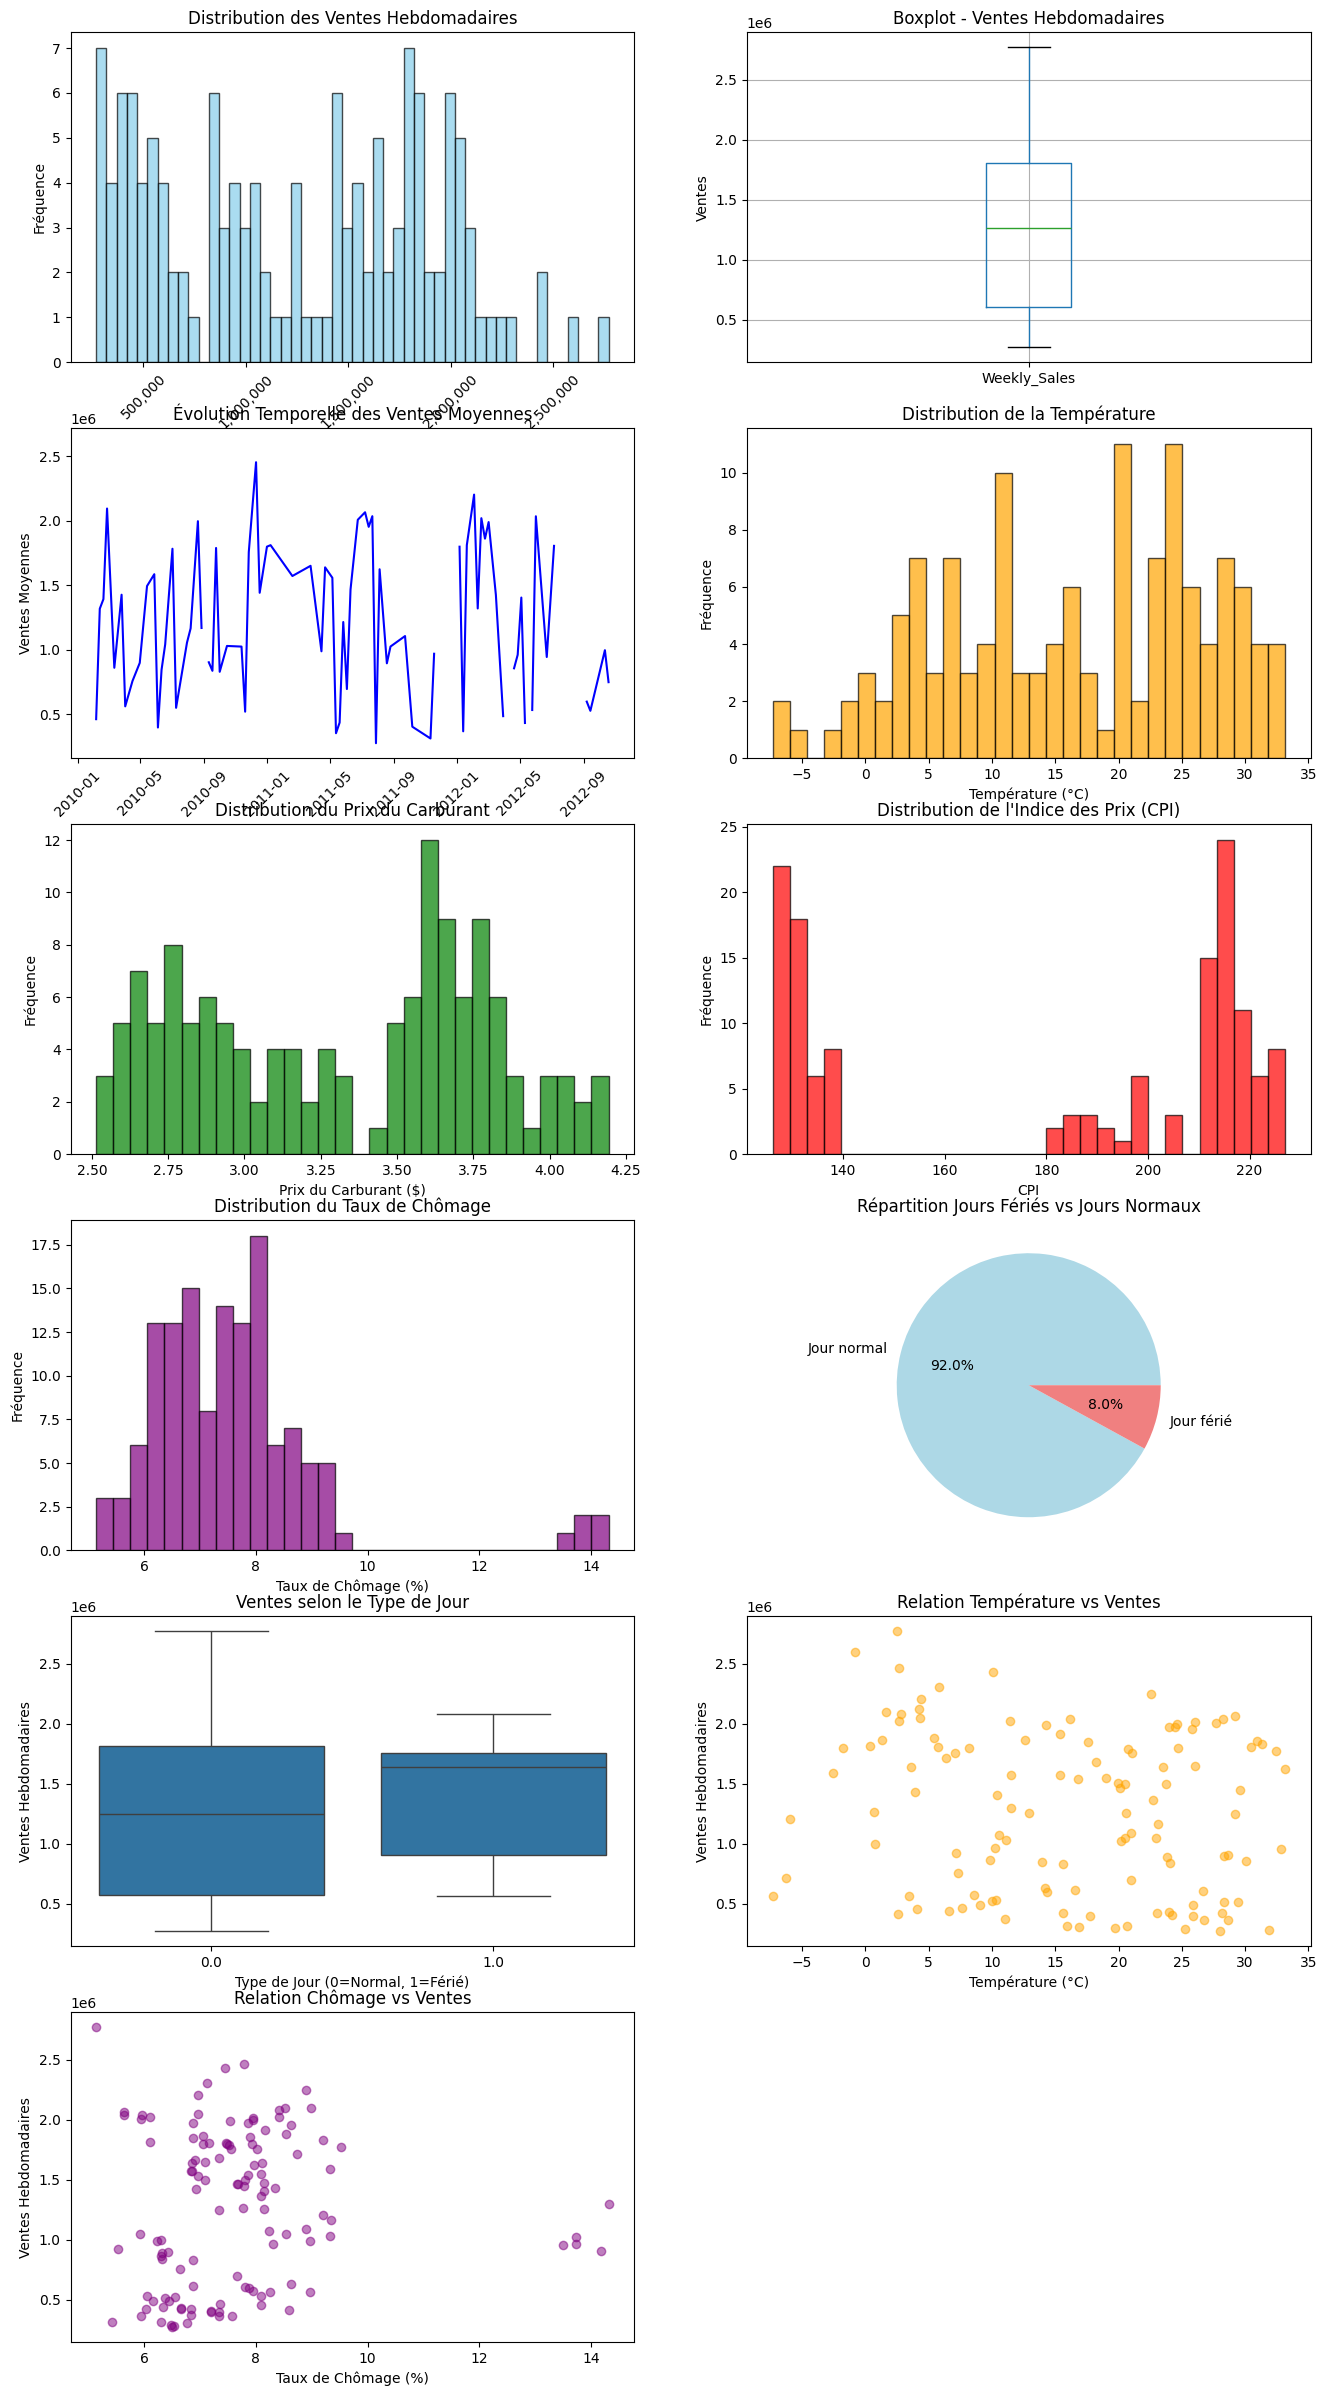

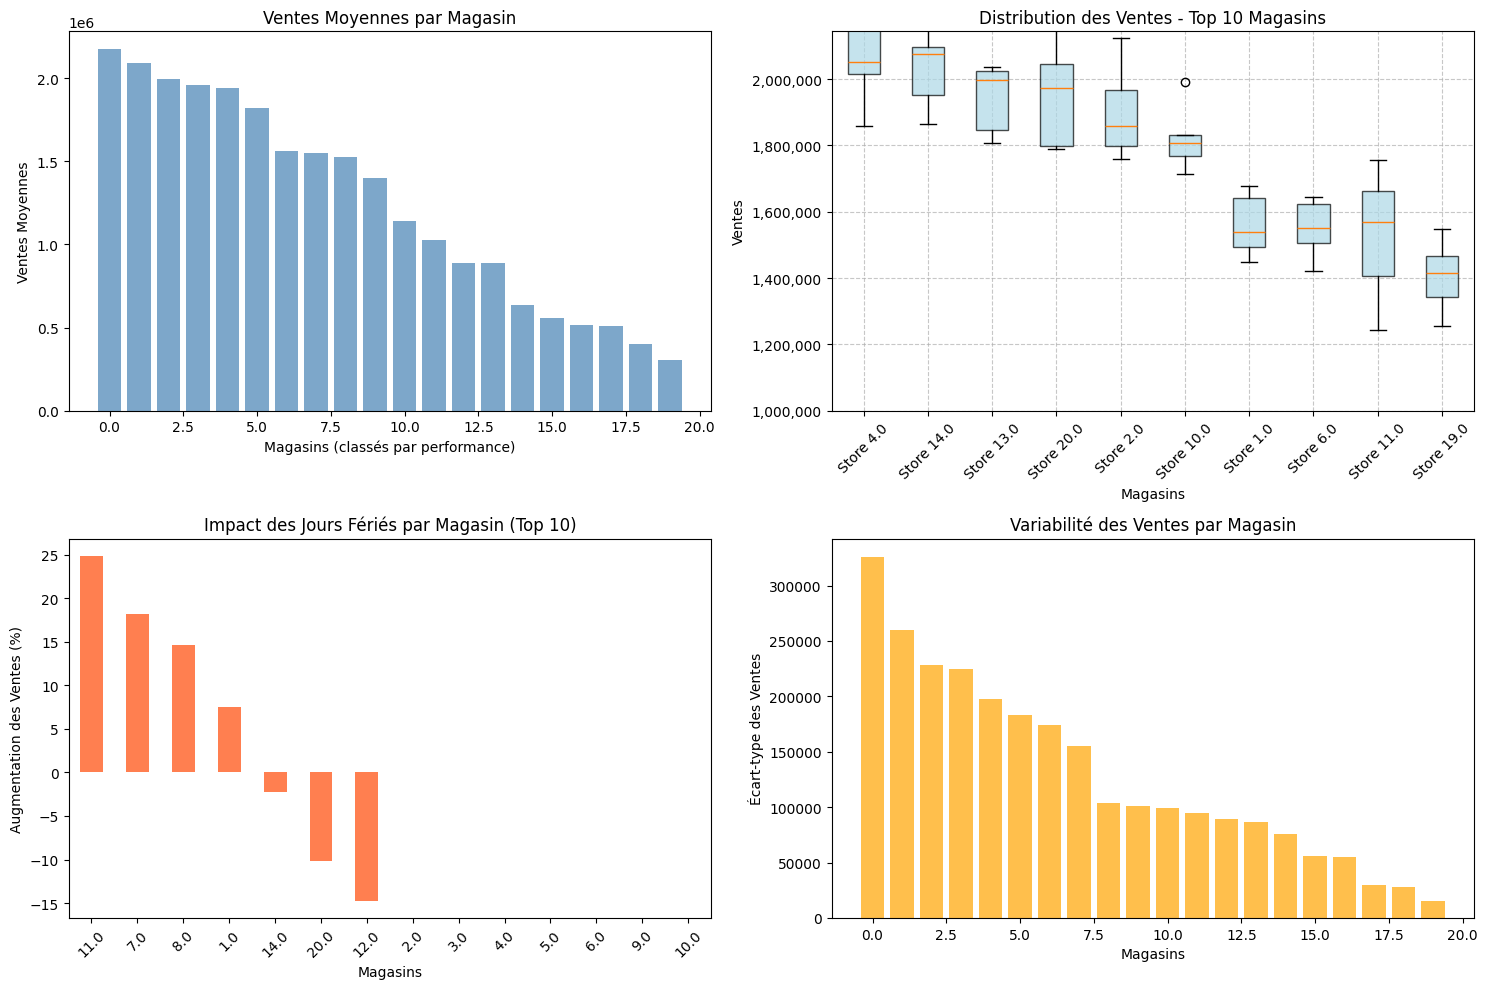


 RÉSUMÉ STATISTIQUE AVANCÉ
----------------------------------------


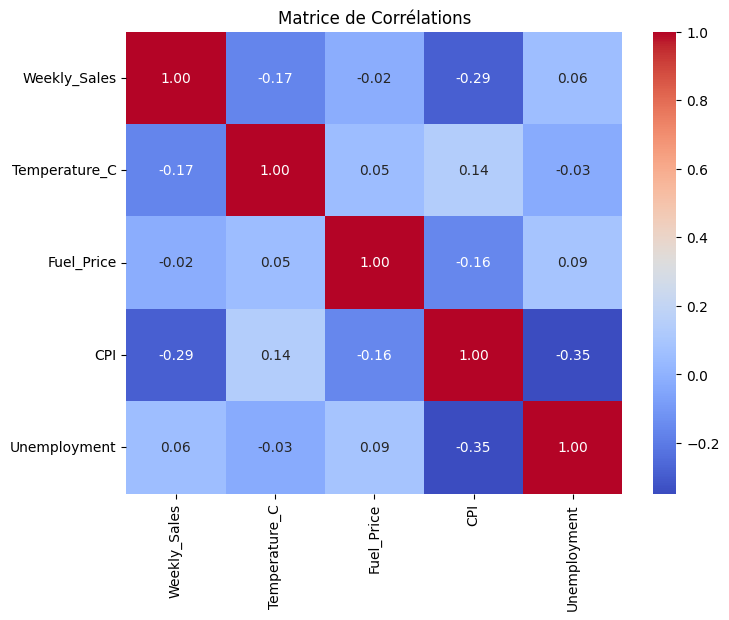

Impact des jours fériés sur les ventes:
                    mean      median        std
Holiday_Flag                                   
0.0           1239575.69  1249738.64  662741.11
1.0           1333024.34  1641957.44  568667.18

 INDICATEURS ÉCONOMIQUES:
Corrélation Chômage-Ventes: 0.055
Corrélation CPI-Ventes: -0.287
Corrélation Prix Carburant-Ventes: -0.019
Corrélation Température-Ventes: -0.166

           FIN DE L'ANALYSE DESCRIPTIVE


In [76]:
# 2. STATISTIQUES DESCRIPTIVES
print("\n STATISTIQUES DESCRIPTIVES")
print("-"*40)

# Conversion Fahrenheit -> Celsius
dataset['Temperature_C'] = (dataset['Temperature'] - 32) * 5/9
dataset['Temperature_C'] = dataset['Temperature_C'].round(2)

# Convertir Date en année / jour de semaine
dataset['Week_Number'] = dataset['Date'].dt.isocalendar().week
dataset['Year'] = dataset['Date'].dt.year
dataset['Weekday'] = dataset['Date'].dt.weekday

# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))

# 3. ANALYSE PAR VARIABLE
plt.figure(figsize=(16, 30))

# VENTES HEBDOMADAIRES
plt.subplot(6, 2, 1)
plt.hist(dataset['Weekly_Sales'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution des Ventes Hebdomadaires')
plt.xlabel('Ventes Hebdomadaires')
plt.ylabel('Fréquence')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

plt.subplot(6, 2, 2)
dataset.boxplot(column='Weekly_Sales', ax=plt.gca())
plt.title('Boxplot - Ventes Hebdomadaires')
plt.ylabel('Ventes')

# Evolution des ventes dans le temps
plt.subplot(6, 2, 3)
ventes_temps = dataset.groupby('Date')['Weekly_Sales'].mean().reset_index()
plt.plot((ventes_temps['Date']), ventes_temps['Weekly_Sales'], 
         linewidth=1.5, color='blue')
plt.title('Évolution Temporelle des Ventes Moyennes')
plt.xlabel('Date')
plt.ylabel('Ventes Moyennes')
plt.xticks(rotation=45)

# TEMPÉRATURE
plt.subplot(6, 2, 4)
plt.hist(dataset['Temperature_C'], bins=30, alpha=0.7, color='orange', edgecolor='black')
plt.title('Distribution de la Température')
plt.xlabel('Température (°C)')
plt.ylabel('Fréquence')

# PRIX DU CARBURANT
plt.subplot(6, 2, 5)
plt.hist(dataset['Fuel_Price'], bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title('Distribution du Prix du Carburant')
plt.xlabel('Prix du Carburant ($)')
plt.ylabel('Fréquence')

# INDICE DES PRIX (CPI)
plt.subplot(6, 2, 6)
plt.hist(dataset['CPI'], bins=30, alpha=0.7, color='red', edgecolor='black')
plt.title('Distribution de l\'Indice des Prix (CPI)')
plt.xlabel('CPI')
plt.ylabel('Fréquence')

# CHÔMAGE
plt.subplot(6, 2, 7)
plt.hist(dataset['Unemployment'], bins=30, alpha=0.7, color='purple', edgecolor='black')
plt.title('Distribution du Taux de Chômage')
plt.xlabel('Taux de Chômage (%)')
plt.ylabel('Fréquence')

# ANALYSE DES JOURS FÉRIÉS
plt.subplot(6, 2, 8)
holiday_counts = dataset['Holiday_Flag'].value_counts()
plt.pie(holiday_counts.values, labels=['Jour normal', 'Jour férié'], autopct='%1.1f%%',
        colors=['lightblue', 'lightcoral'])
plt.title('Répartition Jours Fériés vs Jours Normaux')

# VENTES PAR JOUR FÉRIÉ
plt.subplot(6, 2, 9)
sns.boxplot(data=dataset, x='Holiday_Flag', y='Weekly_Sales')
plt.title('Ventes selon le Type de Jour')
plt.xlabel('Type de Jour (0=Normal, 1=Férié)')
plt.ylabel('Ventes Hebdomadaires')

# CORRÉLATION TEMPÉRATURE-VENTES
plt.subplot(6, 2, 10)
plt.scatter(dataset['Temperature_C'], dataset['Weekly_Sales'], alpha=0.5, color='orange')
plt.title('Relation Température vs Ventes')
plt.xlabel('Température (°C)')
plt.ylabel('Ventes Hebdomadaires')

# CORRÉLATION CHÔMAGE-VENTES
plt.subplot(6, 2, 11)
plt.scatter(dataset['Unemployment'], dataset['Weekly_Sales'], alpha=0.5, color='purple')
plt.title('Relation Chômage vs Ventes')
plt.xlabel('Taux de Chômage (%)')
plt.ylabel('Ventes Hebdomadaires')


# 4. ANALYSE PAR MAGASIN
print("\n ANALYSE PAR MAGASIN")
print("-" * 40)
store_stats = dataset.groupby('Store').agg({
    'Weekly_Sales': ['mean', 'sum', 'std', 'count'],
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean'
}).round(2)

# Top 5 magasins par ventes moyennes
top_stores = dataset.groupby('Store')['Weekly_Sales'].mean().nlargest(5)
bottom_stores = dataset.groupby('Store')['Weekly_Sales'].mean().nsmallest(5)

print("Top 5 magasins (ventes moyennes):")
print(top_stores)
print("\nBottom 5 magasins (ventes moyennes):")
print(bottom_stores)

# Visualisation des performances par magasin
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
store_sales = dataset.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
plt.bar(range(len(store_sales)), store_sales.values, color='steelblue', alpha=0.7)
plt.title('Ventes Moyennes par Magasin')
plt.xlabel('Magasins (classés par performance)')
plt.ylabel('Ventes Moyennes')

# Distribution des ventes - Top 10 magasins
plt.subplot(2, 2, 2)
bp = plt.boxplot(boxplot_data, patch_artist=True)
plt.title('Distribution des Ventes - Top 10 Magasins')
plt.xlabel('Magasins')
plt.ylabel('Ventes')
plt.xticks(range(1, 11), [f'Store {store}' for store in top_10_stores], rotation=45)
for box in bp['boxes']:
    box.set(facecolor='lightblue', alpha=0.7)
    plt.grid(True, linestyle='--', alpha=0.7)
ymin=1_000_000
ymax= dataset['Weekly_Sales'].quantile(0.95)
plt.ylim(ymin, ymax)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Impact des jours fériés
plt.subplot(2, 2, 3)
holiday_impact = dataset.groupby(['Store', 'Holiday_Flag'])['Weekly_Sales'].mean().unstack()
holiday_impact['Impact'] = ((holiday_impact[1] - holiday_impact[0]) / holiday_impact[0]) * 100
holiday_impact['Impact'].sort_values(ascending=False)[:10].plot(kind='bar', color='coral')
plt.title('Impact des Jours Fériés par Magasin (Top 10)')
plt.xlabel('Magasins')
plt.ylabel('Augmentation des Ventes (%)')
plt.xticks(rotation=45)

# Variabilité des ventes par magasin
plt.subplot(2, 2, 4)
store_variability = dataset.groupby('Store')['Weekly_Sales'].std().sort_values(ascending=False)
plt.bar(range(len(store_variability)), store_variability.values, color='orange', alpha=0.7)
plt.title('Variabilité des Ventes par Magasin')
plt.xlabel('Magasins')
plt.ylabel('Écart-type des Ventes')

plt.tight_layout()
plt.show()

# 5. RÉSUMÉ STATISTIQUE AVANCÉ
print("\n RÉSUMÉ STATISTIQUE AVANCÉ")
print("-" * 40)

# Matrice de Corrélations
plt.figure(figsize=(8,6))
sns.heatmap(dataset[['Weekly_Sales','Temperature_C','Fuel_Price','CPI','Unemployment']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de Corrélations")
plt.show()

# Statistiques sur les jours fériés
holiday_stats = dataset.groupby('Holiday_Flag')['Weekly_Sales'].agg(['mean', 'median', 'std']).round(2)
print("Impact des jours fériés sur les ventes:")
print(holiday_stats)

# Indicateurs de performance économique
print(f"\n INDICATEURS ÉCONOMIQUES:")
print(f"Corrélation Chômage-Ventes: {dataset['Unemployment'].corr(dataset['Weekly_Sales']):.3f}")
print(f"Corrélation CPI-Ventes: {dataset['CPI'].corr(dataset['Weekly_Sales']):.3f}")
print(f"Corrélation Prix Carburant-Ventes: {dataset['Fuel_Price'].corr(dataset['Weekly_Sales']):.3f}")
print(f"Corrélation Température-Ventes: {dataset['Temperature_C'].corr(dataset['Weekly_Sales']):.3f}")

print("\n" + "="*60)
print("           FIN DE L'ANALYSE DESCRIPTIVE")
print("="*60)

## Synthèse

# Prétraitement

In [78]:
useless_cols = ["Store", "Date"]

print("Dropping useless columns...")
dataset = dataset.drop(useless_cols, axis=1)
print("...Done.")
print(dataset.head())


Dropping useless columns...
...Done.
   Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price         CPI  \
0    1572117.54           NaN        59.61       3.045  214.777523   
1    1807545.43           0.0        42.38       3.435  128.616064   
2           NaN           0.0          NaN         NaN  130.719581   
3    1244390.03           0.0        84.57         NaN  214.556497   
4    1644470.66           0.0        78.89       2.759  212.412888   

   Unemployment  Temperature_C  Week_Number    Year  Weekday  
0         6.858          15.34            7  2011.0      4.0  
1         7.470           5.77           12  2011.0      4.0  
2         5.936            NaN           30  2012.0      4.0  
3         7.346          29.21         <NA>     NaN      NaN  
4         7.092          26.05           21  2010.0      4.0  


In [ ]:
# Drop lines containing outliers (using masks)

print("Dropping outliers in Weekly Sales...")
to_keep = (dataset["Weekly_Sales"] > 0)
  # We want keeping positives values or missings
dataset = dataset.loc[to_keep, :]
print(f"Numbre de lignes restantes : {dataset.shape[0]}")
print()

"""print("Dropping outliers in Salary...")
to_keep = dataset[["Temperature", "Fuel_Price", "CPI", "Unemployment"]] < dataset[["Temperature", "Fuel_Price", "CPI", "Unemployment"]].mean() + 3 * dataset[["Temperature", "Fuel_Price", "CPI", "Unemployment"]].std()
dataset = dataset.loc[to_keep, :]
print("Done. Number of lines remaining : ", dataset.shape[0])
print()

dataset.head()"""


Dropping outliers in Weekly Sales...
Numbre de lignes restantes : 136

Dropping outliers in Salary...


ValueError: Cannot index with multidimensional key

L'exploration des données ci-dessus permet de savoir quelles étapes de prétraitement seront nécessaires :

1. Prétraitement à prévoir avec pandas

Colonnes inutiles pour la prédiction, à jeter :

id est un identifiant, il ne doit jamais être utilisé pour la prédiction (cette colonne ne contient aucune information)
useless_col sera également inutile, car il contient toujours la même valeur
Colonnes avec trop de valeurs manquantes, à supprimer : almost_empty

Lignes contenant des valeurs aberrantes, supprimées :

Lignes pour lesquelles l'âge est négatif
Lignes pour lesquelles le salaire est à plus de 2 écarts types (std) (ce n'est pas une règle à appliquer en général, mais ici on remarque qu'elle permet d'écarter la valeur de 1 milliard qui semble aberrante)
Variable cible/cible (Y) que nous allons essayer de prédire, pour séparer des autres : Acheté

------------

2. Prétraitements à planifier avec scikit-learn** .

Variables explicatives (X) Nous devons identifier quelles colonnes contiennent des variables catégorielles et quelles colonnes contiennent des variables numériques, car elles seront traitées différemment.

Variables catégorielles : Pays
Variables numériques : Âge, Salaire
Dans cet ensemble de données, nous avons les deux types de variables. Il sera donc nécessaire de prévoir la création d'un numeric_transformer (qui appellera la classe StandardScaler) et d'un categorical_transformer (qui appellera la classe OneHotEncoder). Par ailleurs, si des valeurs sont manquantes dans l'ensemble de données initial, nous devrons prévoir d'appeler la classe SimpleImputer pour les gérer.

Variable cible Y Enfin, il faut ici noter que la variable Y à prédire est catégorielle : il faudra donc prévoir un encodage avec la classe LabelEncoder.